<a href="https://colab.research.google.com/github/SaddamHosen42/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction_Using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction Using ML**

## **Data Load**

In [33]:
import pandas as pd

url = 'https://raw.githubusercontent.com/SaddamHosen42/Heart-Disease-Prediction/refs/heads/main/processed.cleveland.data'


columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

df = pd.read_csv(url, names=columns)

print( df.shape)

(303, 14)


In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## **data preprocessing**

In [32]:
import numpy as np
import pandas as pd


df = df.replace('?', np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.median(numeric_only=True))


display(df.isnull().sum())
display(df.dtypes)

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


# **Data preparation**

## **Separate Features(X) & Target(Y)**

In [23]:
from numpy._core.defchararray import count

X = df.drop('num', axis=1)
Y = df['num']
# Create Y_binary(target value) for Binary Classification
Y_binary = Y.apply(lambda x: 1 if x > 0 else 0)
print(Y_binary.head())

0    0
1    1
2    1
3    0
4    0
Name: num, dtype: int64


In [24]:
display(Y_binary.value_counts())

,count
num,
0,164
1,139


## Data splitting

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y_binary, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (212, 13)
X_test shape: (91, 13)
Y_train shape: (212,)
Y_test shape: (91,)


In [26]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
124,65.0,1.0,1.0,138.0,282.0,1.0,2.0,174.0,0.0,1.4,2.0,1.0,3.0
72,62.0,1.0,4.0,120.0,267.0,0.0,0.0,99.0,1.0,1.8,2.0,2.0,7.0
15,57.0,1.0,3.0,150.0,168.0,0.0,0.0,174.0,0.0,1.6,1.0,0.0,3.0
10,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0
163,58.0,0.0,4.0,100.0,248.0,0.0,2.0,122.0,0.0,1.0,2.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,54.0,1.0,2.0,192.0,283.0,0.0,2.0,195.0,0.0,0.0,1.0,1.0,7.0
71,67.0,1.0,4.0,125.0,254.0,1.0,0.0,163.0,0.0,0.2,2.0,2.0,7.0
106,59.0,1.0,4.0,140.0,177.0,0.0,0.0,162.0,1.0,0.0,1.0,1.0,7.0
270,61.0,1.0,4.0,140.0,207.0,0.0,2.0,138.0,1.0,1.9,1.0,1.0,7.0


In [27]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0
228,54.0,1.0,4.0,110.0,206.0,0.0,2.0,108.0,1.0,0.0,2.0,1.0,3.0
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0
246,58.0,1.0,4.0,100.0,234.0,0.0,0.0,156.0,0.0,0.1,1.0,1.0,7.0
60,51.0,0.0,4.0,130.0,305.0,0.0,0.0,142.0,1.0,1.2,2.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,57.0,1.0,4.0,110.0,201.0,0.0,0.0,126.0,1.0,1.5,2.0,0.0,6.0
19,49.0,1.0,2.0,130.0,266.0,0.0,0.0,171.0,0.0,0.6,1.0,0.0,3.0
143,64.0,1.0,3.0,125.0,309.0,0.0,0.0,131.0,1.0,1.8,2.0,0.0,7.0
79,58.0,1.0,4.0,150.0,270.0,0.0,2.0,111.0,1.0,0.8,1.0,0.0,7.0


In [28]:
Y_train

,num
124,1
72,1
15,0
10,0
163,0
...,...
188,1
71,1
106,1
270,1


In [29]:
Y_test

,num
179,0
228,1
111,1
246,1
60,1
...,...
250,0
19,0
143,1
79,1


# **Scaling**

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (212, 13)
X_test_scaled shape: (91, 13)


# **Models Building**

## Logistic Regression

### Training the model

In [34]:
from sklearn.linear_model import LogisticRegression

logistic_rg_model = LogisticRegression(random_state=42)
logistic_rg_model.fit(X_train_scaled, Y_train)

print("Logistic Regression Model trained")

Logistic Regression Model trained


### Applying the model to make a prediction

In [35]:
Y_pred_log_reg = logistic_rg_model.predict(X_test_scaled)
print("Predicted values for the test set:")
print(Y_pred_log_reg)

Predicted values for the test set:
[1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1
 0 1 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 1
 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 1 1]


### Evaluate model performance

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy_log_reg = accuracy_score(Y_test, Y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_log_reg))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_log_reg))

Logistic Regression Accuracy: 0.8462

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85        48
           1       0.81      0.88      0.84        43

    accuracy                           0.85        91
   macro avg       0.85      0.85      0.85        91
weighted avg       0.85      0.85      0.85        91


Confusion Matrix:
[[39  9]
 [ 5 38]]


### Visualize Confusion Matrix

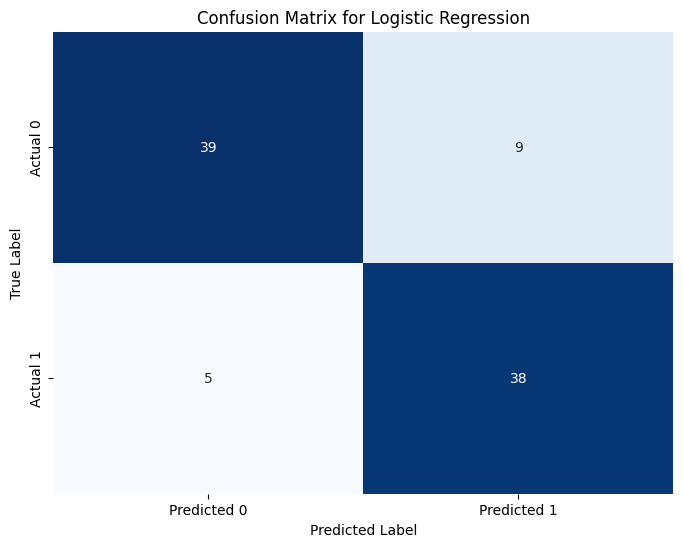

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(Y_test, Y_pred_log_reg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## Random Forest

### Training the model

In [39]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)

random_forest_model.fit(X_train_scaled, Y_train)

print("Random Forest Model trained")

Random Forest Model trained


### Applying the model to make a prediction

In [40]:
Y_pred_random_forest = random_forest_model.predict(X_test_scaled)
print("Predicted values for the test set:")
print(Y_pred_random_forest)

Predicted values for the test set:
[0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0 1
 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 1 0 0 1 1 0 0 1 1
 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 1 1]


### Evaluate model performance

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy_random_forest = accuracy_score(Y_test, Y_pred_random_forest)
print(f"Random Forest Accuracy: {accuracy_random_forest:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_random_forest))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_random_forest))

Random Forest Accuracy: 0.8462

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        48
           1       0.84      0.84      0.84        43

    accuracy                           0.85        91
   macro avg       0.85      0.85      0.85        91
weighted avg       0.85      0.85      0.85        91


Confusion Matrix:
[[41  7]
 [ 7 36]]


### Visualize Confusion Matrix

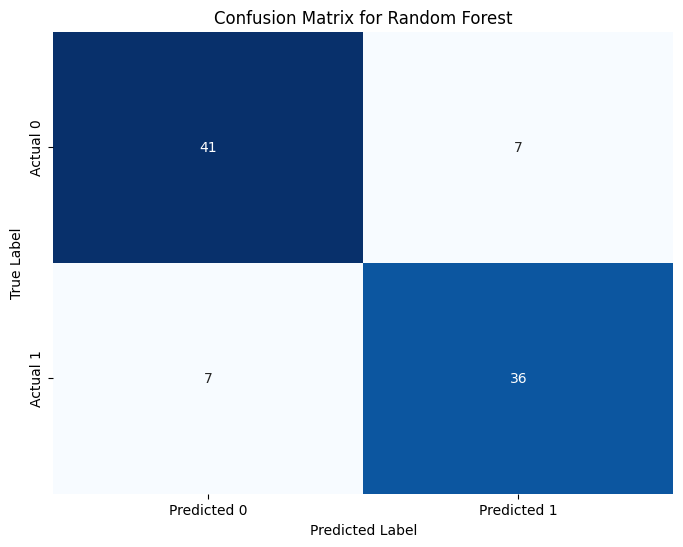

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(Y_test, Y_pred_random_forest)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()

## Decision Tree

### Training the model

In [43]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled, Y_train)

print("Decision Tree Model trained")

Decision Tree Model trained


### Applying the model to make a prediction

In [44]:
Y_pred_decision_tree = decision_tree_model.predict(X_test_scaled)
print("Predicted values for the test set:")
print(Y_pred_decision_tree)

Predicted values for the test set:
[0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 1 0 0 1
 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1
 0 1 0 1 0 1 0 0 0 0 1 1 0 0 1 1 1]


### Evaluate model performance

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy_decision_tree = accuracy_score(Y_test, Y_pred_decision_tree)
print(f"Decision Tree Accuracy: {accuracy_decision_tree:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_decision_tree))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_decision_tree))

Decision Tree Accuracy: 0.6813

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        48
           1       0.67      0.65      0.66        43

    accuracy                           0.68        91
   macro avg       0.68      0.68      0.68        91
weighted avg       0.68      0.68      0.68        91


Confusion Matrix:
[[34 14]
 [15 28]]


### Visualize Confusion Matrix

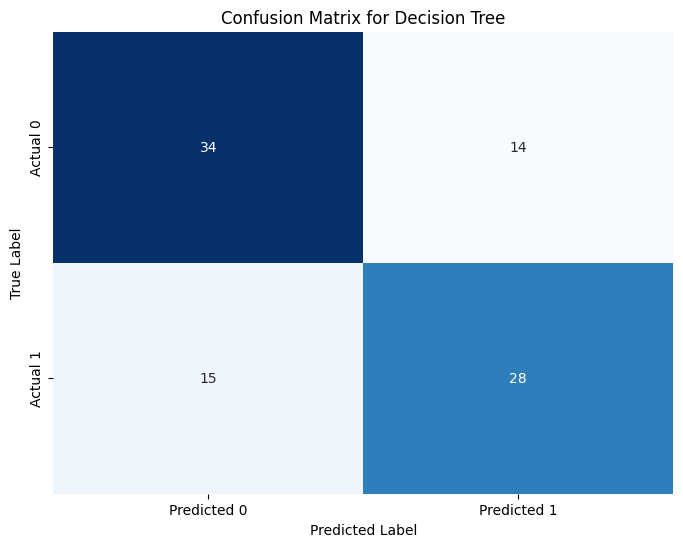

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_dt = confusion_matrix(Y_test, Y_pred_decision_tree)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

# Model **comparison**

In [47]:
from sklearn.metrics import classification_report
import pandas as pd

# Get metrics for Logistic Regression
report_log_reg = classification_report(Y_test, Y_pred_log_reg, output_dict=True)
f1_log_reg = report_log_reg['1']['f1-score']
recall_log_reg = report_log_reg['1']['recall']

# Get metrics for Random Forest
report_random_forest = classification_report(Y_test, Y_pred_random_forest, output_dict=True)
f1_random_forest = report_random_forest['1']['f1-score']
recall_random_forest = report_random_forest['1']['recall']

# Get metrics for Decision Tree
report_decision_tree = classification_report(Y_test, Y_pred_decision_tree, output_dict=True)
f1_decision_tree = report_decision_tree['1']['f1-score']
recall_decision_tree = report_decision_tree['1']['recall']

# Create a dictionary to store model performance metrics
model_performance = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [accuracy_log_reg, accuracy_random_forest, accuracy_decision_tree],
    'F1 (Class 1)': [f1_log_reg, f1_random_forest, f1_decision_tree],
    'Recall (Class 1)': [recall_log_reg, recall_random_forest, recall_decision_tree]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(model_performance)

# Display the DataFrame
display(performance_df)

,Model,Accuracy,F1 (Class 1),Recall (Class 1)
0,Logistic Regression,0.846154,0.844444,0.883721
1,Random Forest,0.846154,0.837209,0.837209
2,Decision Tree,0.681319,0.658824,0.651163
